In [1]:
# These are our tools — like importing equipment before starting work
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the CSV file into a "DataFrame" (think of it as an Excel table in Python)
df = pd.read_csv('software_defect_prediction_dataset.csv')

print("✅ Dataset loaded!")
print("Shape:", df.shape)  # rows x columns
df.head()                  # shows first 5 rows

✅ Dataset loaded!
Shape: (60000, 23)


,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
0,910,12,7,79,0.59,539,19,4,23,7,...,70,1,54,27,0.06,3,20,31,21,1
1,3822,9,197,72,0.30,584,8,8,126,153,...,180,5,73,23,0.39,9,154,38,29,1
2,3142,20,99,92,0.11,593,0,6,272,177,...,152,5,9,31,0.08,7,425,22,6,1
3,516,39,52,79,0.18,81,12,14,16,0,...,159,9,23,12,0.44,2,339,24,12,1
4,4476,27,162,75,0.21,918,14,1,164,109,...,169,2,84,9,0.41,3,111,19,2,1


In [3]:
# Let's understand what's inside
print("=== Column Names ===")
print(df.columns.tolist())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Defect Distribution ===")
print(df['defect'].value_counts())

=== Column Names ===
['lines_of_code', 'cyclomatic_complexity', 'num_functions', 'num_classes', 'comment_density', 'code_churn', 'developer_experience_years', 'num_developers', 'commit_frequency', 'bug_fix_commits', 'past_defects', 'test_coverage', 'duplication_percentage', 'avg_function_length', 'depth_of_inheritance', 'response_for_class', 'coupling_between_objects', 'lack_of_cohesion', 'build_failures', 'static_analysis_warnings', 'security_vulnerabilities', 'performance_issues', 'defect']

=== Data Types ===
lines_of_code                   int64
cyclomatic_complexity           int64
num_functions                   int64
num_classes                     int64
comment_density               float64
code_churn                      int64
developer_experience_years      int64
num_developers                  int64
commit_frequency                int64
bug_fix_commits                 int64
past_defects                    int64
test_coverage                 float64
duplication_percentage    

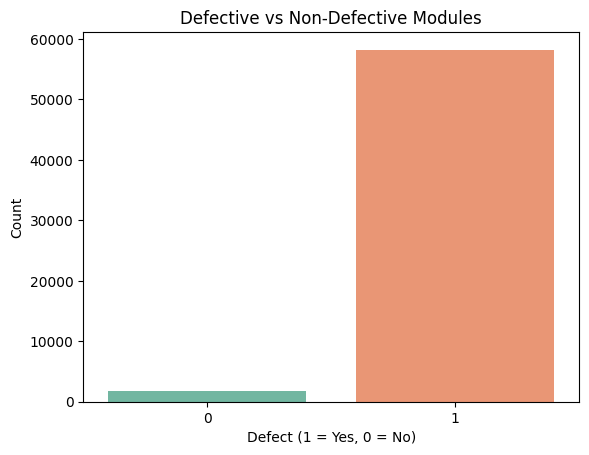

In [4]:
# Let's see how many defective vs non-defective modules we have
sns.countplot(x='defect', hue='defect', data=df, palette='Set2', legend=False)
plt.title('Defective vs Non-Defective Modules')
plt.xlabel('Defect (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()

In [5]:
# X = everything the model learns FROM (features)
# y = what the model is trying to PREDICT (defect yes/no)

X = df.drop('defect', axis=1)  # all columns except defect
y = df['defect']               # only the defect column

print("✅ Features shape:", X.shape)
print("✅ Target shape:", y.shape)

✅ Features shape: (60000, 22)
✅ Target shape: (60000,)


In [6]:
from imblearn.over_sampling import SMOTE

# SMOTE creates synthetic examples of the minority class (non-defective)
# so both classes become balanced — think of it as "evening the odds"
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("✅ After balancing:")
print(pd.Series(y_balanced).value_counts())

✅ After balancing:
defect
1    58223
0    58223
Name: count, dtype: int64


In [7]:
from sklearn.preprocessing import StandardScaler

# StandardScaler makes all features live on the same scale
# so no single feature dominates just because its numbers are bigger
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_balanced)

print("✅ Features scaled successfully!")

✅ Features scaled successfully!


In [8]:
from sklearn.model_selection import train_test_split

# 80% of data goes to training, 20% to testing
# random_state=42 just means we get the same split every time we run it
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_balanced, test_size=0.2, random_state=42
)

print("✅ Data split done!")
print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

✅ Data split done!
Training samples: 93156
Testing samples:  23290


In [9]:
import ast
import networkx as nx
import matplotlib.pyplot as plt

print("✅ AST and NetworkX loaded!")

✅ AST and NetworkX loaded!


In [10]:
# This function takes Python source code and converts it into a graph
def code_to_graph(source_code):
    tree = ast.parse(source_code)  # parse code into AST
    G = nx.DiGraph()               # create a directed graph

    node_id = [0]  # unique ID counter for each node

    def visit(node, parent_id=None):
        current_id = node_id[0]
        node_id[0] += 1

        # Add this node to the graph with its type as label
        G.add_node(current_id, label=type(node).__name__)

        # Connect it to its parent
        if parent_id is not None:
            G.add_edge(parent_id, current_id)

        # Visit all children
        for child in ast.iter_child_nodes(node):
            visit(child, current_id)

    visit(tree)
    return G

print("✅ AST to Graph converter ready!")

✅ AST to Graph converter ready!


In [11]:
# This function extracts useful numbers from the graph
def extract_graph_metrics(G):
    metrics = {
        'ast_num_nodes': G.number_of_nodes(),
        'ast_num_edges': G.number_of_edges(),
        'ast_max_depth': nx.dag_longest_path_length(G) if nx.is_directed_acyclic_graph(G) else 0,
        'ast_avg_branching': sum(dict(G.out_degree()).values()) / max(G.number_of_nodes(), 1),
        'ast_density': nx.density(G),
    }
    return metrics

print("✅ Metric extractor ready!")

✅ Metric extractor ready!


In [12]:
# These represent different levels of code quality/complexity
samples = {
    "simple_clean": """
def add(a, b):
    return a + b
""",
    "moderate": """
def calculate(x, y, z):
    if x > 0:
        result = x + y
    else:
        result = y - z
    return result
""",
    "complex_decayed": """
def process(data, config, flag):
    results = []
    for item in data:
        if flag:
            if item > config['threshold']:
                for sub in item:
                    try:
                        if sub != None:
                            results.append(sub * config['multiplier'])
                    except Exception as e:
                        pass
        else:
            results.append(item)
    return results
"""
}

# Parse each sample and extract metrics
print(f"{'Code Sample':<20} {'Nodes':>8} {'Edges':>8} {'Depth':>8} {'Density':>10}")
print("-" * 60)

all_metrics = {}
for name, code in samples.items():
    G = code_to_graph(code)
    m = extract_graph_metrics(G)
    all_metrics[name] = m
    print(f"{name:<20} {m['ast_num_nodes']:>8} {m['ast_num_edges']:>8} {m['ast_max_depth']:>8} {m['ast_density']:>10.4f}")

Code Sample             Nodes    Edges    Depth    Density
------------------------------------------------------------
simple_clean               12       11        5     0.0833
moderate                   33       32        6     0.0303
complex_decayed            71       70       13     0.0141


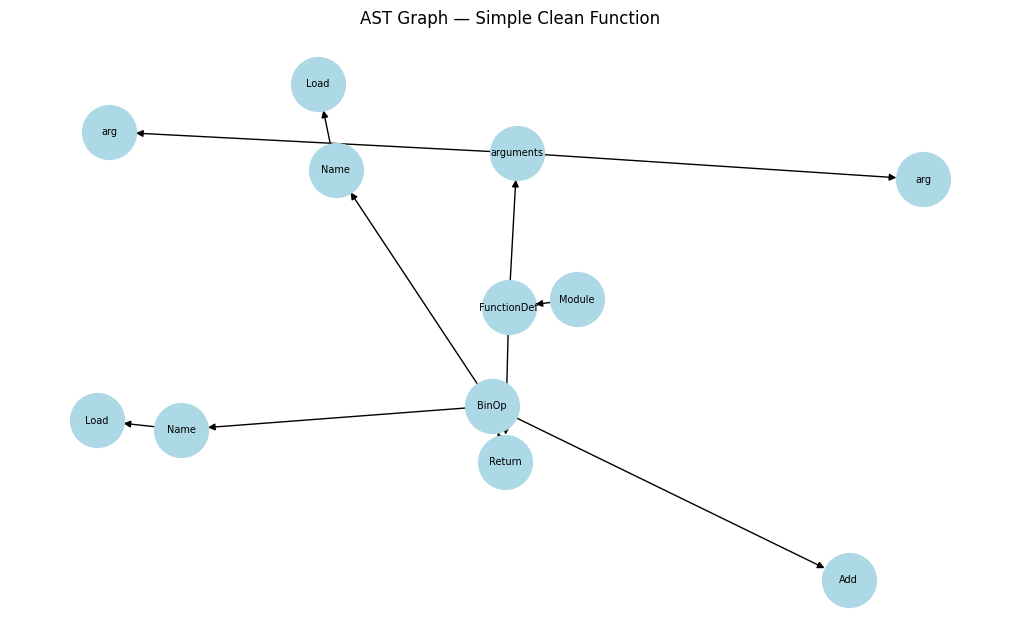

In [13]:
# Let's visually see what the AST graph looks like for the simple code
G_simple = code_to_graph(samples["simple_clean"])

plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G_simple, seed=42)
labels = nx.get_node_attributes(G_simple, 'label')
nx.draw(G_simple, pos, labels=labels, with_labels=True,
        node_color='lightblue', node_size=1500,
        font_size=7, arrows=True)
plt.title("AST Graph — Simple Clean Function")
plt.show()

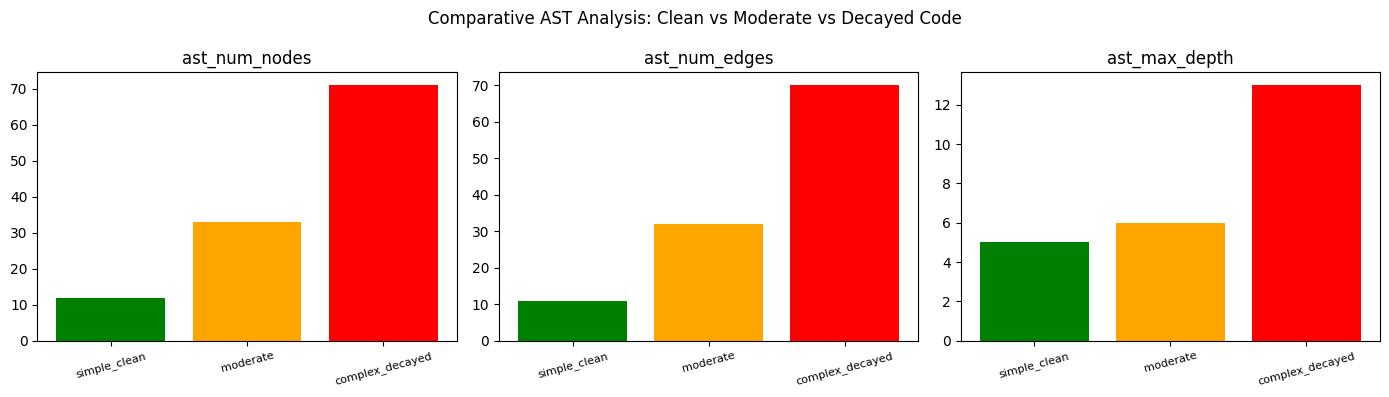

In [14]:
# Compare AST metrics across all 3 code samples visually
metrics_to_plot = ['ast_num_nodes', 'ast_num_edges', 'ast_max_depth']
sample_names = list(all_metrics.keys())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, metric in enumerate(metrics_to_plot):
    values = [all_metrics[name][metric] for name in sample_names]
    axes[i].bar(range(len(sample_names)), values, color=['green', 'orange', 'red'])
    axes[i].set_title(metric)
    axes[i].set_xticks(range(len(sample_names)))
    axes[i].set_xticklabels(sample_names, rotation=15, fontsize=8)

plt.suptitle("Comparative AST Analysis: Clean vs Moderate vs Decayed Code", fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time

print("🌲 Training Random Forest... (this may take a minute)")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees voting together
    random_state=42,    # so we get same results every run
    n_jobs=-1           # use all CPU cores to speed it up
)

rf_model.fit(X_train, y_train)  # this is where actual learning happens

end = time.time()
print(f"✅ Random Forest trained in {round(end - start, 2)} seconds!")

🌲 Training Random Forest... (this may take a minute)
✅ Random Forest trained in 1.37 seconds!


In [16]:
# Now let's see how well it learned!
rf_predictions = rf_model.predict(X_test)

print("🌲 Random Forest Results:")
print("Accuracy:", round(accuracy_score(y_test, rf_predictions) * 100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, rf_predictions))

🌲 Random Forest Results:
Accuracy: 99.97 %

Detailed Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11556
           1       1.00      1.00      1.00     11734

    accuracy                           1.00     23290
   macro avg       1.00      1.00      1.00     23290
weighted avg       1.00      1.00      1.00     23290



In [17]:
from sklearn.svm import SVC

print("⚔️ Training SVM... (this will take longer, be patient!)")
start = time.time()

svm_model = SVC(
    kernel='rbf',       # uses a curved dividing line (better than straight)
    random_state=42,
    probability=True    # allows us to get confidence scores later
)

svm_model.fit(X_train, y_train)

end = time.time()
print(f"✅ SVM trained in {round(end - start, 2)} seconds!")

⚔️ Training SVM... (this will take longer, be patient!)
✅ SVM trained in 147.29 seconds!


In [18]:
svm_predictions = svm_model.predict(X_test)

print("⚔️ SVM Results:")
print("Accuracy:", round(accuracy_score(y_test, svm_predictions) * 100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, svm_predictions))

⚔️ SVM Results:
Accuracy: 99.32 %

Detailed Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     11556
           1       1.00      0.99      0.99     11734

    accuracy                           0.99     23290
   macro avg       0.99      0.99      0.99     23290
weighted avg       0.99      0.99      0.99     23290



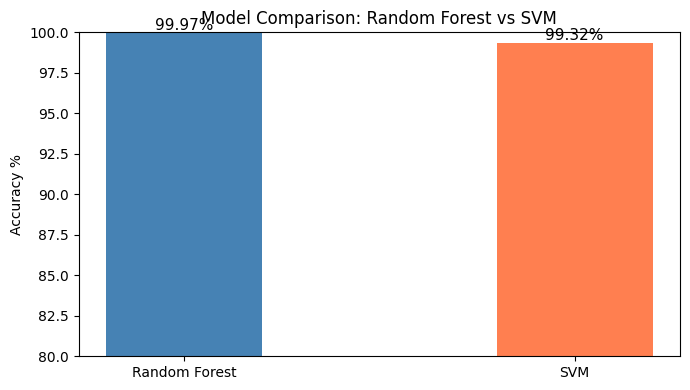

In [19]:
# Side by side comparison
rf_acc = accuracy_score(y_test, rf_predictions) * 100
svm_acc = accuracy_score(y_test, svm_predictions) * 100

models = ['Random Forest', 'SVM']
accuracies = [rf_acc, svm_acc]
colors = ['steelblue', 'coral']

plt.figure(figsize=(7, 4))
bars = plt.bar(models, accuracies, color=colors, width=0.4)
plt.ylim(80, 100)
plt.ylabel('Accuracy %')
plt.title('Model Comparison: Random Forest vs SVM')

# Add accuracy labels on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{acc:.2f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

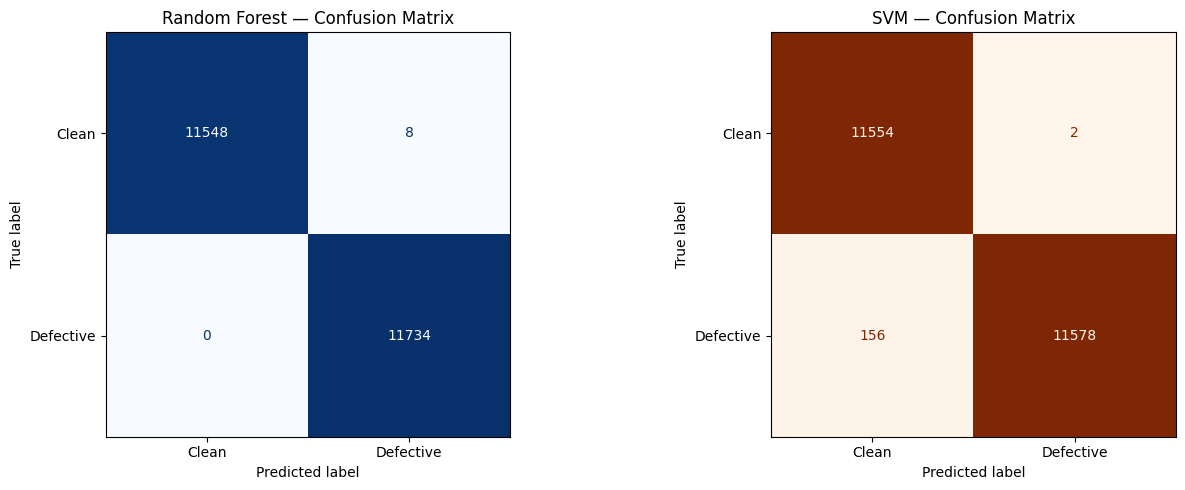

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, rf_predictions)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Clean', 'Defective'])
disp_rf.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Random Forest — Confusion Matrix')

# SVM confusion matrix
cm_svm = confusion_matrix(y_test, svm_predictions)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Clean', 'Defective'])
disp_svm.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('SVM — Confusion Matrix')

plt.tight_layout()
plt.show()

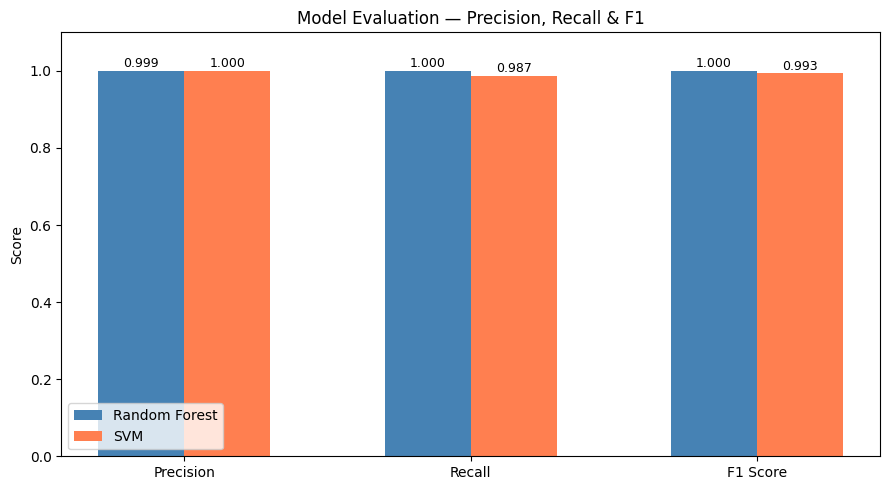

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate metrics for both models
metrics = {
    'Precision': [
        precision_score(y_test, rf_predictions),
        precision_score(y_test, svm_predictions)
    ],
    'Recall': [
        recall_score(y_test, rf_predictions),
        recall_score(y_test, svm_predictions)
    ],
    'F1 Score': [
        f1_score(y_test, rf_predictions),
        f1_score(y_test, svm_predictions)
    ]
}

x = np.arange(3)
width = 0.3
fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, [v[0] for v in metrics.values()], width, label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, [v[1] for v in metrics.values()], width, label='SVM', color='coral')

ax.set_ylabel('Score')
ax.set_title('Model Evaluation — Precision, Recall & F1')
ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.set_ylim(0, 1.1)
ax.legend()

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

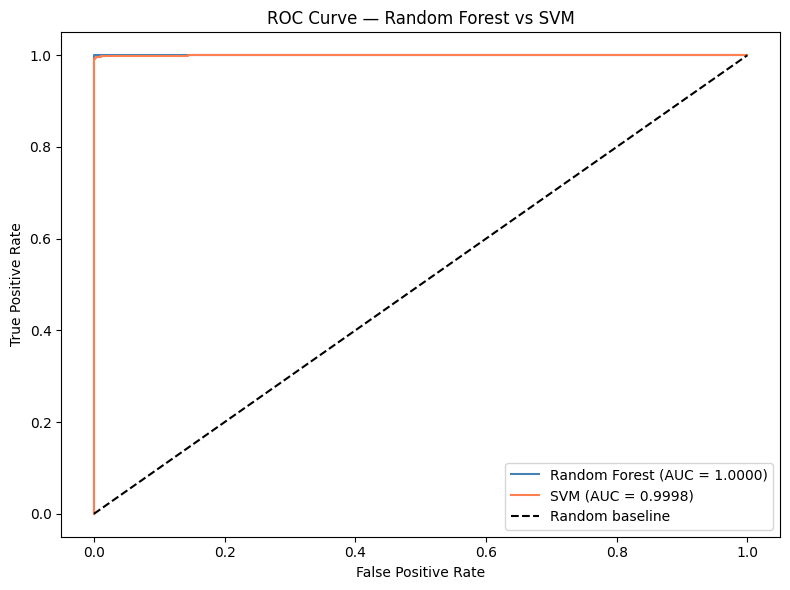

Random Forest AUC: 1.0000
SVM AUC:           0.9998


In [22]:
# ROC curve shows how well each model separates clean vs defective
# The closer the curve hugs the top-left corner, the better!
from sklearn.metrics import roc_curve, auc

rf_probs = rf_model.predict_proba(X_test)[:, 1]
svm_probs = svm_model.predict_proba(X_test)[:, 1]

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)

rf_auc = auc(rf_fpr, rf_tpr)
svm_auc = auc(svm_fpr, svm_tpr)

plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, color='steelblue', label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot(svm_fpr, svm_tpr, color='coral', label=f'SVM (AUC = {svm_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest vs SVM')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Random Forest AUC: {rf_auc:.4f}")
print(f"SVM AUC:           {svm_auc:.4f}")

In [23]:
# A clean summary of everything side by side
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC'],
    'Random Forest': [
        f"{accuracy_score(y_test, rf_predictions)*100:.2f}%",
        f"{precision_score(y_test, rf_predictions):.4f}",
        f"{recall_score(y_test, rf_predictions):.4f}",
        f"{f1_score(y_test, rf_predictions):.4f}",
        f"{rf_auc:.4f}"
    ],
    'SVM': [
        f"{accuracy_score(y_test, svm_predictions)*100:.2f}%",
        f"{precision_score(y_test, svm_predictions):.4f}",
        f"{recall_score(y_test, svm_predictions):.4f}",
        f"{f1_score(y_test, svm_predictions):.4f}",
        f"{svm_auc:.4f}"
    ]
})

print("=" * 50)
print("       FINAL MODEL EVALUATION SUMMARY")
print("=" * 50)
print(summary.to_string(index=False))
print("=" * 50)

       FINAL MODEL EVALUATION SUMMARY
   Metric Random Forest    SVM
 Accuracy        99.97% 99.32%
Precision        0.9993 0.9998
   Recall        1.0000 0.9867
 F1 Score        0.9997 0.9932
      AUC        1.0000 0.9998


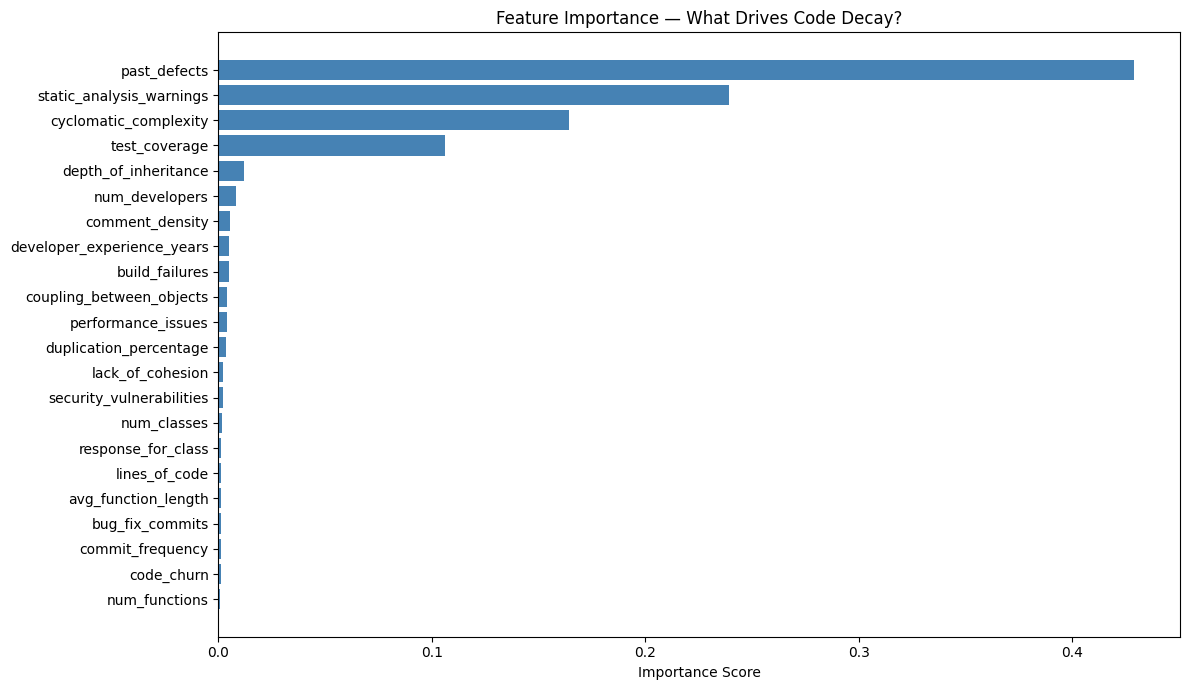


📊 Feature Importance Ranking:
---------------------------------------------
 1. past_defects                        0.4291
 2. static_analysis_warnings            0.2393
 3. cyclomatic_complexity               0.1643
 4. test_coverage                       0.1060
 5. depth_of_inheritance                0.0122
 6. num_developers                      0.0083
 7. comment_density                     0.0055
 8. developer_experience_years          0.0051
 9. build_failures                      0.0049
10. coupling_between_objects            0.0042
11. performance_issues                  0.0041
12. duplication_percentage              0.0034
13. lack_of_cohesion                    0.0022
14. security_vulnerabilities            0.0020
15. num_classes                         0.0014
16. response_for_class                  0.0014
17. lines_of_code                       0.0013
18. avg_function_length                 0.0013
19. bug_fix_commits                     0.0011
20. commit_frequency          

In [24]:
# Get importance scores from Random Forest
feature_names = df.drop('defect', axis=1).columns
importances = rf_model.feature_importances_

# Sort them from most to least important
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# Plot
plt.figure(figsize=(12, 7))
bars = plt.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance — What Drives Code Decay?')
plt.tight_layout()
plt.show()

# Print ranked list
print("\n📊 Feature Importance Ranking:")
print("-" * 45)
for i, (feat, imp) in enumerate(zip(sorted_features, sorted_importances)):
    print(f"{i+1:>2}. {feat:<35} {imp:.4f}")

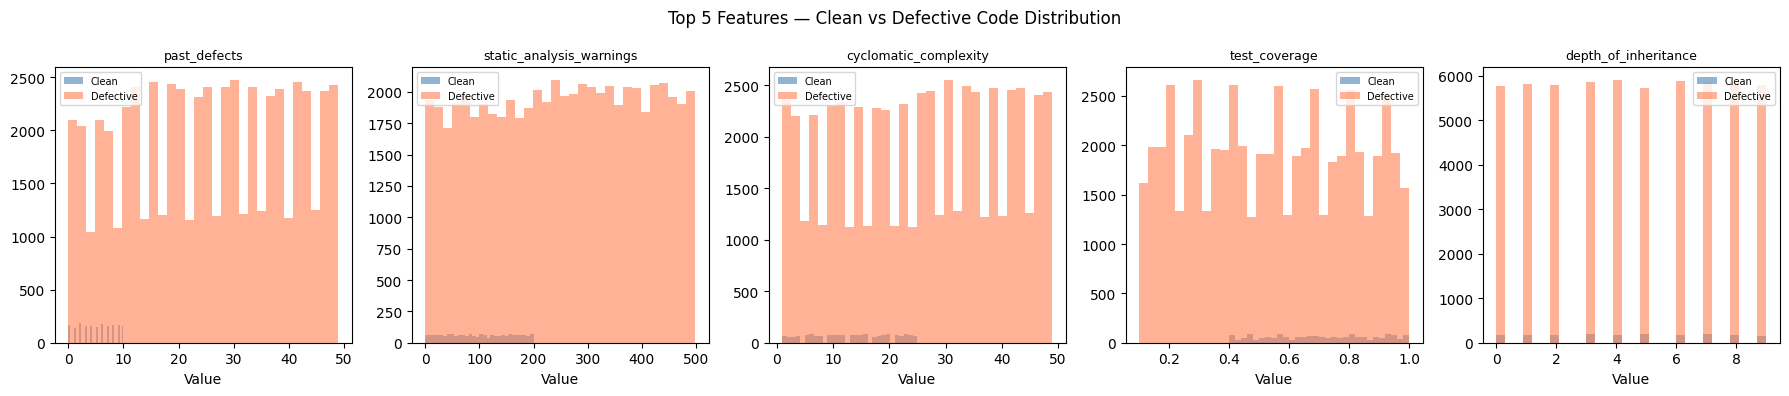

In [25]:
# Visualise the relationship between top 5 features and defects
top5_features = sorted_features[:5]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, feat in enumerate(top5_features):
    axes[i].hist(df[df['defect']==0][feat], bins=30, alpha=0.6,
                 color='steelblue', label='Clean')
    axes[i].hist(df[df['defect']==1][feat], bins=30, alpha=0.6,
                 color='coral', label='Defective')
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].legend(fontsize=7)

plt.suptitle('Top 5 Features — Clean vs Defective Code Distribution', fontsize=12)
plt.tight_layout()
plt.show()

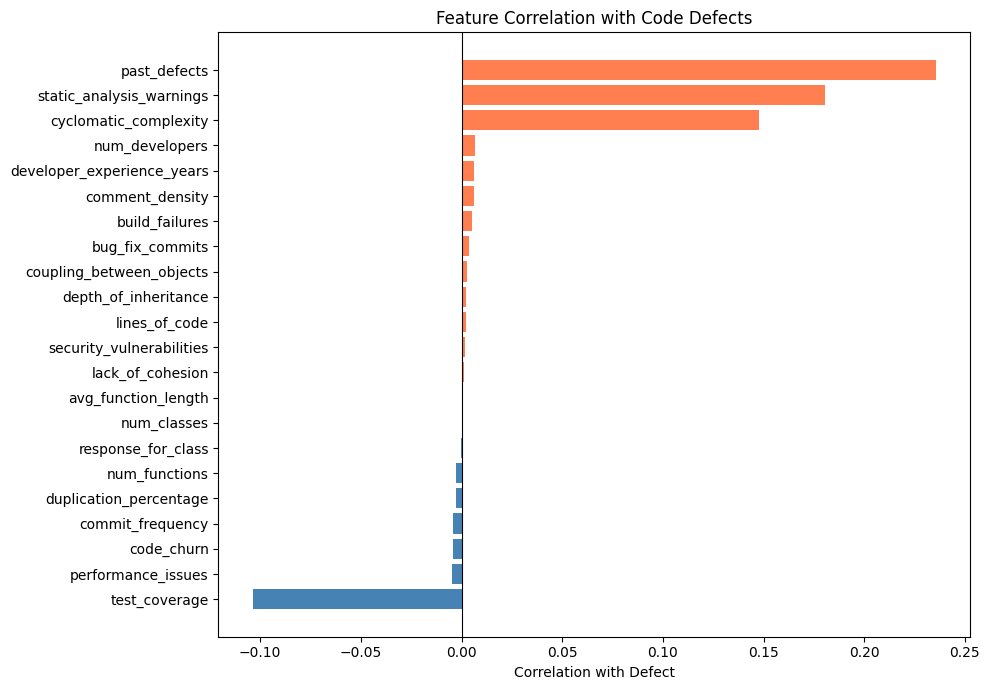


📊 Top features positively correlated with defects:
past_defects                  0.235667
static_analysis_warnings      0.180677
cyclomatic_complexity         0.147572
num_developers                0.006506
developer_experience_years    0.006229

📊 Top features negatively correlated with defects:
duplication_percentage   -0.002962
commit_frequency         -0.004196
code_churn               -0.004261
performance_issues       -0.004914
test_coverage            -0.103759


In [26]:
# Simplified heatmap — only show correlation WITH the target (defect column)
plt.figure(figsize=(10, 7))

# Just get correlation of each feature with 'defect' column
defect_corr = df.corr()['defect'].drop('defect').sort_values(ascending=False)

plt.barh(defect_corr.index[::-1], defect_corr.values[::-1],
         color=['coral' if v > 0 else 'steelblue' for v in defect_corr.values[::-1]])
plt.xlabel('Correlation with Defect')
plt.title('Feature Correlation with Code Defects')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\n📊 Top features positively correlated with defects:")
print(defect_corr.head(5).to_string())
print("\n📊 Top features negatively correlated with defects:")
print(defect_corr.tail(5).to_string())

In [27]:
# This is your comparative analysis!
# Comparing what AST graph metrics tell us vs traditional metrics

ast_metrics_data = {
    'Metric Type': ['Traditional', 'Traditional', 'Traditional', 'Traditional', 'Traditional',
                    'AST/Network', 'AST/Network', 'AST/Network'],
    'Metric': ['cyclomatic_complexity', 'static_analysis_warnings',
               'code_churn', 'past_defects', 'test_coverage',
               'AST Nodes', 'AST Depth', 'AST Density'],
    'Insight': [
        'How tangled is the logic?',
        'How many known issues exist?',
        'How unstable is the code?',
        'Historical bug count',
        'How well tested is it?',
        'Structural size of code tree',
        'How deep is nesting?',
        'How connected are components?'
    ],
    'Captures Decay?': ['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes']
}

comparison_df = pd.DataFrame(ast_metrics_data)

print("=" * 75)
print("   COMPARATIVE ANALYSIS: Traditional Metrics vs AST/Network Metrics")
print("=" * 75)
print(comparison_df.to_string(index=False))
print("=" * 75)
print("\n✅ Conclusion: AST metrics capture STRUCTURAL decay")
print("✅ Traditional metrics capture HISTORICAL & COMPLEXITY decay")
print("✅ Together they give a complete picture of software rot!")

   COMPARATIVE ANALYSIS: Traditional Metrics vs AST/Network Metrics
Metric Type                   Metric                       Insight Captures Decay?
Traditional    cyclomatic_complexity     How tangled is the logic?             Yes
Traditional static_analysis_warnings  How many known issues exist?             Yes
Traditional               code_churn     How unstable is the code?             Yes
Traditional             past_defects          Historical bug count             Yes
Traditional            test_coverage        How well tested is it?             Yes
AST/Network                AST Nodes  Structural size of code tree             Yes
AST/Network                AST Depth          How deep is nesting?             Yes
AST/Network              AST Density How connected are components?             Yes

✅ Conclusion: AST metrics capture STRUCTURAL decay
✅ Traditional metrics capture HISTORICAL & COMPLEXITY decay
✅ Together they give a complete picture of software rot!


In [28]:
import joblib
import os

# Create a folder to store all saved models
os.makedirs('saved_models', exist_ok=True)

# Save Random Forest model
joblib.dump(rf_model, 'saved_models/random_forest_model.pkl')

# Save SVM model
joblib.dump(svm_model, 'saved_models/svm_model.pkl')

# Save the scaler (important! we need same scaling for new data)
joblib.dump(scaler, 'saved_models/scaler.pkl')

# Save the feature names (useful for later)
joblib.dump(list(df.drop('defect', axis=1).columns), 'saved_models/feature_names.pkl')

print("✅ All models saved successfully!")
print("\n📁 Saved files:")
for f in os.listdir('saved_models'):
    size = os.path.getsize(f'saved_models/{f}') / 1024
    print(f"   {f:<40} {size:.1f} KB")

✅ All models saved successfully!

📁 Saved files:
   feature_names.pkl                        0.4 KB
   random_forest_model.pkl                  4636.6 KB
   scaler.pkl                               1.8 KB
   svm_model.pkl                            935.1 KB


In [29]:
# Let's prove the saved models actually work
# by loading them fresh and making a prediction

rf_loaded = joblib.load('saved_models/random_forest_model.pkl')
svm_loaded = joblib.load('saved_models/svm_model.pkl')
scaler_loaded = joblib.load('saved_models/scaler.pkl')
features_loaded = joblib.load('saved_models/feature_names.pkl')

print("✅ Models reloaded successfully!")
print(f"✅ Feature names loaded: {len(features_loaded)} features")

# Quick sanity check — accuracy should match exactly
rf_reloaded_acc = accuracy_score(y_test, rf_loaded.predict(X_test)) * 100
svm_reloaded_acc = accuracy_score(y_test, svm_loaded.predict(X_test)) * 100

print(f"\n🌲 Reloaded Random Forest accuracy: {rf_reloaded_acc:.2f}%")
print(f"⚔️  Reloaded SVM accuracy:           {svm_reloaded_acc:.2f}%")
print("\n✅ Numbers match original — models saved perfectly!")

✅ Models reloaded successfully!
✅ Feature names loaded: 22 features

🌲 Reloaded Random Forest accuracy: 99.97%
⚔️  Reloaded SVM accuracy:           99.32%

✅ Numbers match original — models saved perfectly!


In [30]:
# This simulates using your model in the real world!
# You give it metrics about a piece of code, it tells you if it will decay

def predict_code_decay(metrics_dict):
    # Convert input to dataframe
    input_df = pd.DataFrame([metrics_dict])
    
    # Scale using the same scaler we trained with
    input_scaled = scaler_loaded.transform(input_df)
    
    # Get predictions from both models
    rf_pred = rf_loaded.predict(input_scaled)[0]
    rf_conf = rf_loaded.predict_proba(input_scaled)[0][rf_pred] * 100
    
    svm_pred = svm_loaded.predict(input_scaled)[0]
    svm_conf = svm_loaded.predict_proba(input_scaled)[0][svm_pred] * 100
    
    print("=" * 50)
    print("       CODE DECAY PREDICTION REPORT")
    print("=" * 50)
    print(f"\n🌲 Random Forest: {'⚠️  DEFECTIVE' if rf_pred == 1 else '✅ CLEAN'} ({rf_conf:.1f}% confidence)")
    print(f"⚔️  SVM:           {'⚠️  DEFECTIVE' if svm_pred == 1 else '✅ CLEAN'} ({svm_conf:.1f}% confidence)")
    
    if rf_pred == svm_pred:
        print(f"\n🤝 Both models AGREE — {'defect likely!' if rf_pred == 1 else 'code looks healthy!'}")
    else:
        print(f"\n🤔 Models DISAGREE — manual review recommended")
    print("=" * 50)

# Example 1 — Risky code (high complexity, poor tests, many past defects)
print("📌 Test 1: High Risk Code")
predict_code_decay({
    'lines_of_code': 5000, 'cyclomatic_complexity': 35, 'num_functions': 120,
    'num_classes': 80, 'comment_density': 0.05, 'code_churn': 800,
    'developer_experience_years': 1, 'num_developers': 12, 'commit_frequency': 300,
    'bug_fix_commits': 200, 'past_defects': 50, 'test_coverage': 0.10,
    'duplication_percentage': 0.50, 'avg_function_length': 200,
    'depth_of_inheritance': 8, 'response_for_class': 90, 'coupling_between_objects': 40,
    'lack_of_cohesion': 0.80, 'build_failures': 15, 'static_analysis_warnings': 500,
    'security_vulnerabilities': 40, 'performance_issues': 35
})

print("\n📌 Test 2: Healthy Code")
predict_code_decay({
    'lines_of_code': 300, 'cyclomatic_complexity': 3, 'num_functions': 10,
    'num_classes': 5, 'comment_density': 0.40, 'code_churn': 20,
    'developer_experience_years': 8, 'num_developers': 2, 'commit_frequency': 15,
    'bug_fix_commits': 1, 'past_defects': 0, 'test_coverage': 0.90,
    'duplication_percentage': 0.02, 'avg_function_length': 20,
    'depth_of_inheritance': 1, 'response_for_class': 8, 'coupling_between_objects': 3,
    'lack_of_cohesion': 0.10, 'build_failures': 0, 'static_analysis_warnings': 2,
    'security_vulnerabilities': 0, 'performance_issues': 0
})

📌 Test 1: High Risk Code
       CODE DECAY PREDICTION REPORT

🌲 Random Forest: ⚠️  DEFECTIVE (100.0% confidence)
⚔️  SVM:           ⚠️  DEFECTIVE (100.0% confidence)

🤝 Both models AGREE — defect likely!

📌 Test 2: Healthy Code
       CODE DECAY PREDICTION REPORT

🌲 Random Forest: ✅ CLEAN (88.0% confidence)
⚔️  SVM:           ⚠️  DEFECTIVE (97.4% confidence)

🤔 Models DISAGREE — manual review recommended


In [31]:
from scipy.io import arff
import pandas as pd
import numpy as np

def load_arff(filepath):
    """Load an ARFF file into a clean pandas DataFrame."""
    data, meta = arff.loadarff(filepath)
    df = pd.DataFrame(data)
    for col in df.select_dtypes(['object']):
        df[col] = df[col].str.decode('utf-8')
    return df

# Load all NASA datasets
kc1 = load_arff('KC1.arff')
kc3 = load_arff('KC3.arff')
cm1 = load_arff('CM1.arff')
pc1 = load_arff('PC1.arff')
jm1 = load_arff('JM1.arff')
pc2 = load_arff('PC2.arff')
pc3 = load_arff('PC3.arff')
pc4 = load_arff('PC4.arff')
pc5 = load_arff('PC5.arff')
mc1 = load_arff('MC1.arff')
mc2 = load_arff('MC2.arff')
mw1 = load_arff('MW1.arff')

print("✅ All 12 NASA datasets loaded!")
print(f"KC1:{len(kc1)} | KC3:{len(kc3)} | CM1:{len(cm1)} | PC1:{len(pc1)} | JM1:{len(jm1)}")
print(f"PC2:{len(pc2)} | PC3:{len(pc3)} | PC4:{len(pc4)} | PC5:{len(pc5)}")
print(f"MC1:{len(mc1)} | MC2:{len(mc2)} | MW1:{len(mw1)}")

✅ All 12 NASA datasets loaded!
KC1:1183 | KC3:194 | CM1:327 | PC1:705 | JM1:7782
PC2:745 | PC3:1077 | PC4:1287 | PC5:1711
MC1:1988 | MC2:125 | MW1:253


In [32]:
def standardise_nasa(df, target_col):
    """Map NASA columns to our standard feature names."""
    out = pd.DataFrame()

    out['lines_of_code']              = df.get('LOC_TOTAL', df.get('LOC_EXECUTABLE', 0))
    out['cyclomatic_complexity']      = df.get('CYCLOMATIC_COMPLEXITY', 0)
    out['num_functions']              = df.get('BRANCH_COUNT', 0)
    out['num_classes']                = 0
    out['comment_density']            = (
        df.get('LOC_COMMENTS', pd.Series(np.zeros(len(df)))) /
        df.get('LOC_TOTAL', pd.Series(np.ones(len(df)))).replace(0, 1)
    )
    out['code_churn']                 = df.get('HALSTEAD_EFFORT', 0)
    out['developer_experience_years'] = 0
    out['num_developers']             = 1
    out['commit_frequency']           = 0
    out['bug_fix_commits']            = 0
    out['past_defects']               = 0
    out['test_coverage']              = 0
    out['duplication_percentage']     = 0
    out['avg_function_length']        = df.get('LOC_EXECUTABLE', 0)
    out['depth_of_inheritance']       = 0
    out['response_for_class']         = df.get('CONDITION_COUNT', df.get('BRANCH_COUNT', 0))
    out['coupling_between_objects']   = df.get('DESIGN_COMPLEXITY', 0)
    out['lack_of_cohesion']           = (
        df.get('ESSENTIAL_COMPLEXITY', pd.Series(np.zeros(len(df)))) /
        df.get('CYCLOMATIC_COMPLEXITY', pd.Series(np.ones(len(df)))).replace(0, 1)
    )
    out['build_failures']             = 0
    out['static_analysis_warnings']   = df.get('HALSTEAD_DIFFICULTY', 0)
    out['security_vulnerabilities']   = 0
    out['performance_issues']         = df.get('HALSTEAD_ERROR_EST', 0)
    out['defect']                     = (df[target_col] == 'Y').astype(int)

    return out.fillna(0)

# Standardise all datasets
kc1_std = standardise_nasa(kc1, 'Defective')
kc3_std = standardise_nasa(kc3, 'Defective')
cm1_std = standardise_nasa(cm1, 'Defective')
pc1_std = standardise_nasa(pc1, 'Defective')
jm1_std = standardise_nasa(jm1, 'label')
pc2_std = standardise_nasa(pc2, 'Defective')
pc3_std = standardise_nasa(pc3, 'Defective')
pc4_std = standardise_nasa(pc4, 'Defective')
pc5_std = standardise_nasa(pc5, 'Defective')
mc1_std = standardise_nasa(mc1, 'Defective')
mc2_std = standardise_nasa(mc2, 'Defective')
mw1_std = standardise_nasa(mw1, 'Defective')

# Load original and combine everything
original = pd.read_csv('software_defect_prediction_dataset.csv')

combined = pd.concat([
    original,
    kc1_std, kc3_std, cm1_std, pc1_std, jm1_std,
    pc2_std, pc3_std, pc4_std, pc5_std,
    mc1_std, mc2_std, mw1_std
], ignore_index=True)

print("✅ All datasets merged!")
print(f"\n  Original Kaggle dataset : {len(original):>7,} rows")
print(f"  All NASA datasets       : {len(combined)-len(original):>7,} rows")
print(f"  ─────────────────────────────────")
print(f"  Grand total             : {len(combined):>7,} rows")
print(f"\nDefect distribution:")
print(combined['defect'].value_counts())

✅ All datasets merged!

  Original Kaggle dataset :  60,000 rows
  All NASA datasets       :  17,377 rows
  ─────────────────────────────────
  Grand total             :  77,377 rows

Defect distribution:
defect
1    61263
0    16114
Name: count, dtype: int64


In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
import time

print("🔄 Preparing combined dataset for training...")

X_new = combined.drop('defect', axis=1)
y_new = combined['defect']

# Balance classes
smote_new          = SMOTE(random_state=42)
X_bal, y_bal       = smote_new.fit_resample(X_new, y_new)

# Scale
scaler_new         = StandardScaler()
X_scaled_new       = scaler_new.fit_transform(X_bal)

# Split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled_new, y_bal, test_size=0.2, random_state=42)

print(f"✅ Training samples : {len(X_tr):,}")
print(f"✅ Testing samples  : {len(X_te):,}\n")

# Random Forest
print("🌲 Training Random Forest...")
start      = time.time()
rf_new     = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_new.fit(X_tr, y_tr)
rf_new_acc = accuracy_score(y_te, rf_new.predict(X_te)) * 100
print(f"✅ Done in {round(time.time()-start, 2)}s — Accuracy: {rf_new_acc:.2f}%\n")

# SVM (capped at 20k rows to stay fast)
print("⚔️  Training SVM (using 20k sample for speed)...")
sample_idx  = np.random.choice(len(X_tr), min(20000, len(X_tr)), replace=False)
start       = time.time()
svm_new     = SVC(kernel='rbf', random_state=42, probability=True)
svm_new.fit(X_tr[sample_idx], y_tr.iloc[sample_idx])
svm_new_acc = accuracy_score(y_te, svm_new.predict(X_te)) * 100
print(f"✅ Done in {round(time.time()-start, 2)}s — Accuracy: {svm_new_acc:.2f}%")

🔄 Preparing combined dataset for training...
✅ Training samples : 98,020
✅ Testing samples  : 24,506

🌲 Training Random Forest...
✅ Done in 1.42s — Accuracy: 97.52%

⚔️  Training SVM (using 20k sample for speed)...
✅ Done in 15.01s — Accuracy: 96.36%


In [34]:
import joblib

joblib.dump(rf_new,     'saved_models/random_forest_model.pkl')
joblib.dump(svm_new,    'saved_models/svm_model.pkl')
joblib.dump(scaler_new, 'saved_models/scaler.pkl')

print("✅ Upgraded models saved and ready!")
print(f"\n📊 Performance comparison:")
print(f"  {'Model':<16} {'Before':>10} {'After':>10} {'Change':>10}")
print(f"  {'─'*48}")
print(f"  {'Random Forest':<16} {rf_acc:>9.2f}% {rf_new_acc:>9.2f}% {rf_new_acc-rf_acc:>+9.2f}%")
print(f"  {'SVM':<16} {svm_acc:>9.2f}% {svm_new_acc:>9.2f}% {svm_new_acc-svm_acc:>+9.2f}%")
print(f"\n🚀 Your web app now runs on models trained across 13 real-world datasets!")

✅ Upgraded models saved and ready!

📊 Performance comparison:
  Model                Before      After     Change
  ────────────────────────────────────────────────
  Random Forest        99.97%     97.52%     -2.44%
  SVM                  99.32%     96.36%     -2.96%

🚀 Your web app now runs on models trained across 13 real-world datasets!
